In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_pickle('../../data/figure_7_islands/island-fixation-david-lol.pkl')

In [58]:
df

,N,r,p1
0,2,1.000000,0.000000
1,2,1.002513,0.000000
2,2,1.005025,0.000000
3,2,1.007538,0.000000
4,2,1.010050,0.000000
...,...,...,...
2995,30,1.489950,0.346392
2996,30,1.492462,0.345105
2997,30,1.494975,0.343827
2998,30,1.497487,0.342558


In [59]:
df['dist-to-1/2'] = abs(df['p1']-.5)

In [60]:
df

,N,r,p1,dist-to-1/2
0,2,1.000000,0.000000,0.500000
1,2,1.002513,0.000000,0.500000
2,2,1.005025,0.000000,0.500000
3,2,1.007538,0.000000,0.500000
4,2,1.010050,0.000000,0.500000
...,...,...,...,...
2995,30,1.489950,0.346392,0.153608
2996,30,1.492462,0.345105,0.154895
2997,30,1.494975,0.343827,0.156173
2998,30,1.497487,0.342558,0.157442


In [ ]:
rdf = df.loc[df.groupby('N')['dist-to-1/2'].idxmin()]
rdf = rdf[rdf['dist-to-1/2'] < 1e-2]
rdf.N.astype(int)
rdf

,N,r,p1,dist-to-1/2
800,10,1.000000,0.498659,0.001341
1036,12,1.090452,0.500803,0.000803
1260,14,1.150754,0.499991,0.000009
1475,16,1.188442,0.500799,0.000799
1686,18,1.216080,0.499698,0.000302
1893,20,1.233668,0.500217,0.000217
2098,22,1.246231,0.500553,0.000553
2302,24,1.256281,0.499956,0.000044
2505,26,1.263819,0.499345,0.000655
2707,28,1.268844,0.499389,0.000611


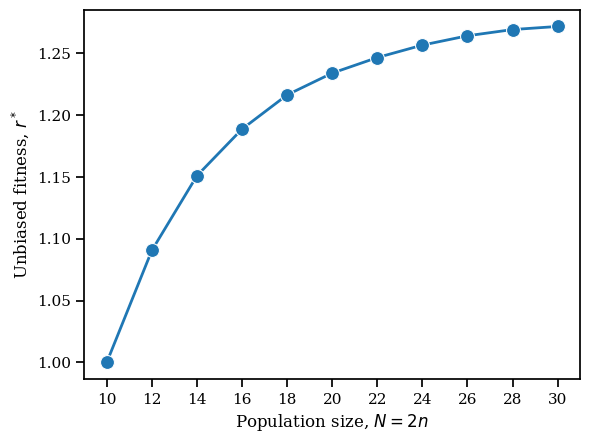

In [ ]:
with sns.plotting_context('notebook'), plt.rc_context({"font.family": "serif"}):
  g = sns.lineplot(
    rdf,
    x='N',
    y='r',
    marker='o',
    lw=2,
    ms=10,
  )
  g.set(
    xlabel='Population size, $N=2n$',
    ylabel='Unbiased fitness, $r^*$',
    xticks=rdf.N.unique(),
  )

  g.figure.savefig('../../figs/figure_7_islands/split-r.eps', transparent=True)

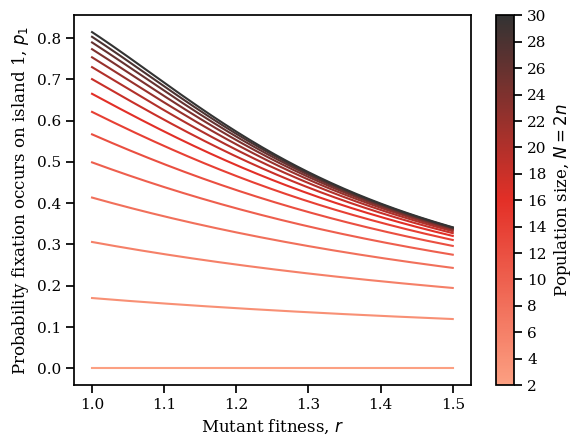

In [ ]:
import matplotlib as mpl
cmap = sns.color_palette('Reds_d', as_cmap=True)
with sns.plotting_context('notebook'), plt.rc_context({"font.family": "serif"}):
  g = sns.lineplot(df, x='r', y='p1', hue='N', palette=cmap, legend=False)
  g.set(xlabel='Mutant fitness, $r$', ylabel='Probability fixation occurs on island 1, $p_1$')
  norm = mpl.colors.Normalize(
    vmin=df["N"].min(),
    vmax=df["N"].max(),
  )

  sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
  cbar = g.figure.colorbar(sm, ax=g, label="Population size, $N=2n$")
  cbar.set_ticks(df.N.unique())
  g.figure.savefig('../../figs/figure_7_islands/fixation-location.eps', transparent=True)